In [1]:
import numpy as np
import matplotlib.pyplot as plt
from solver import LaplaceSolver, Solver, plotPredVSMeas

In [2]:
FIGW: int = 8

In [3]:
#Layer parameters-------------------------------------------------------------
q: float = 1e-6
xm_0: np.ndarray = np.array([0.0, 0.14, 0.16, 0.22, 0.26, 0.62, 0.72, 0.83, 0.86, 0.87])
xm_1: np.ndarray = np.array([0.14, 0.16, 0.22, 0.26, 0.62, 0.72, 0.83, 0.86, 0.87, 1])
lambm: np.ndarray = np.repeat(1.0032, len(xm_0))
Cm: np.ndarray = np.repeat(2.09, len(xm_0))
km: np.ndarray = np.repeat(1.0, len(xm_0))

#BC--------------------------------------------------------------------------
alphaM1,alphaM2 = 1,0 #Dirichlet bottom BC
surface_times = np.array([0,1])/q
surface_temps = 1 + 2*q*surface_times

#IC--------------------------------------------------------------------------
interface_temps = np.repeat(0.0, len(xm_0)+1)

#Solvers----------------------------------------------------------------
CITT_slvr = Solver(xm_0, xm_1, q, lambm, Cm, km, surface_temps, surface_times, alphaM1, alphaM2, interface_temps)
CITT_slvr.nonDimensionalize()
Lap_slvr = LaplaceSolver(CITT_slvr.Um[0], CITT_slvr.Dm[0], CITT_slvr.surface_temps[0], np.diff(CITT_slvr.surface_temps)/np.diff(CITT_slvr.surface_times))

Check the nondimensional parameters

In [4]:
print('Dm:', CITT_slvr.Dm)
print('Um:', CITT_slvr.Um)
print('km:', CITT_slvr.km)

Dm: [0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24 0.24]
Um: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
km: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


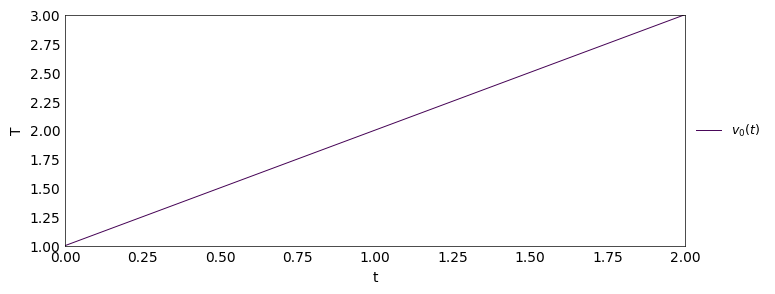

In [5]:
CITT_slvr.plotInletBCs(fig_width=FIGW)

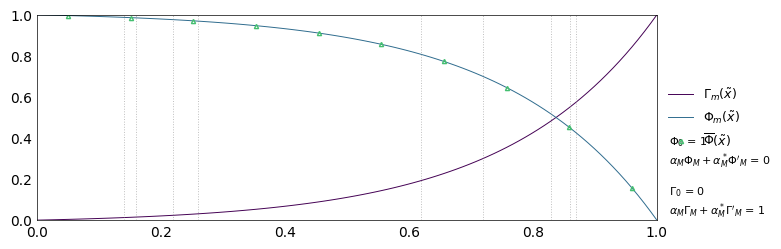

In [6]:
CITT_slvr.calcStdSolParams()
CITT_slvr.plotSteadySol(fig_width=FIGW, add_sinh_sol=True)

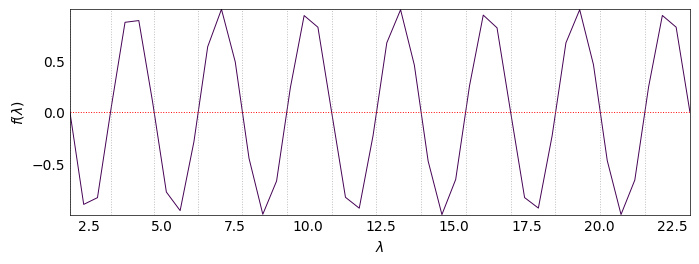

In [7]:
CITT_slvr.findEigenvalues(15, fig_width=FIGW)

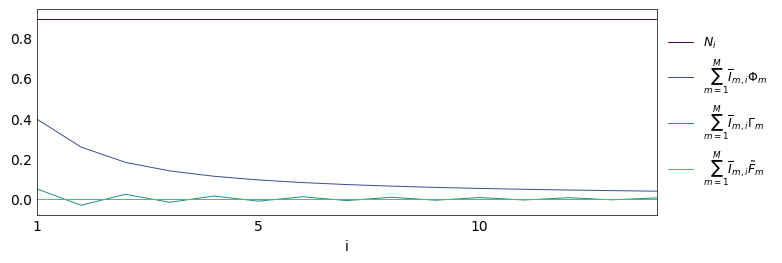

In [8]:
CITT_slvr.calcTransSolParams()
CITT_slvr.plotConvergence(fig_width=FIGW)

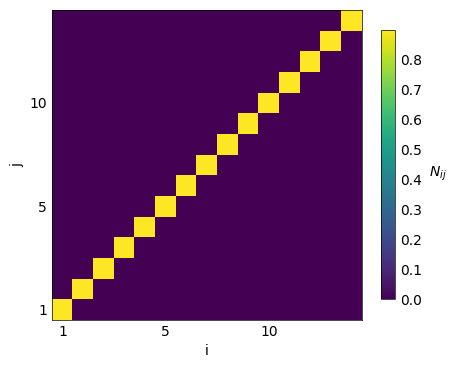

In [9]:
CITT_slvr.plotOrthogonality(print_results=False, fig_width=5)

Calculate and plot the results

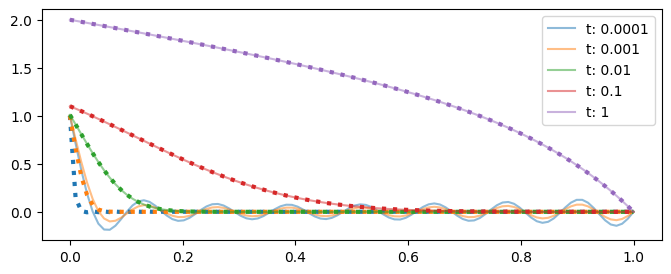

In [10]:
x_array = np.linspace(0,1,100)
t_array = np.logspace(-4, 0,5)

#Laplace data---------------------------------------------------------------------
T_laplace = Lap_slvr.calcFinalSol(x_array, t_array, N_terms=100)

#CITT data-----------------------------------------------------------------------
T_citt = CITT_slvr.calcFinalSol(x_array, t_array)

#plot the data--------------------------------------------------------------------
fig = plt.figure(figsize=(FIGW, 3))
ax = fig.add_subplot(1,1,1)

for idx, t in enumerate(t_array):
    line = ax.plot(x_array, T_citt[idx], alpha=0.5, label=f't: {t:.1g}')[0]
    ax.plot(x_array, T_laplace[idx], linestyle=':', linewidth=3, color=line.get_color())

ax.legend()
plt.show()
